# Test 5: Classical MLP Replacement ⚠️ GPU RECOMMENDED

Replace the quantum circuit (24 params) with a classical MLP of similar capacity.
Fine-tune with frozen backbone. If it matches the quantum model, no quantum advantage.

**Key question:** Can a classical function of equal parameter count replace the quantum circuit?

In [1]:
from setup_helpers import *
from ariel_quantum_regression.training import (
    gather_labeled_batch, batch_indices, move_prepared_data_to_device
)

ckpt = load_checkpoint()
model, model_cfg, device = build_trained_model(ckpt)
data = load_data()

HAS_GPU = torch.cuda.is_available()
print(f"GPU available: {HAS_GPU}")
if not HAS_GPU:
    print("WARNING: This test is slow on CPU. Consider running on GPU.")

GPU available: False


In [2]:
class ClassicalReplacementBlock(nn.Module):
    """Drop-in replacement for QuantumBlock: 8→8 with tanh to match [-1,1] range.
    Linear(8,3) + Linear(3,8) + Tanh = 8*3+3 + 3*8+8 = 59 params (close to 24 circuit params).
    """
    def __init__(self, n_qubits=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_qubits, 3, bias=True),
            nn.Tanh(),
            nn.Linear(3, n_qubits, bias=True),
            nn.Tanh(),
        )

    def forward(self, inputs):
        return self.net(inputs)

replacement = ClassicalReplacementBlock(model_cfg.qnn_qubits)
n_replacement_params = sum(p.numel() for p in replacement.parameters())
n_circuit_params = sum(p.numel() for p in model.quantum_block.parameters())
print(f"Quantum circuit params: {n_circuit_params}")
print(f"Classical replacement params: {n_replacement_params}")

Quantum circuit params: 24
Classical replacement params: 59


In [3]:
# Build a fresh copy of the model with the classical replacement
# (Avoid deepcopy — PennyLane qnodes/devices may not support it)
model_mlp, _, _ = build_trained_model(ckpt)
model_mlp.quantum_block = replacement.to(device)

# Freeze everything except replacement block + quantum_head + quantum_gate
model_mlp.set_backbone_trainable(False)
for p in model_mlp.projector.parameters():
    p.requires_grad_(False)

trainable = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)
print(f"Trainable params for fine-tuning: {trainable:,}")

Trainable params for fine-tuning: 51,909


In [4]:
# Fine-tune the replacement block + quantum_head
from copy import deepcopy

FINETUNE_EPOCHS = 15
FINETUNE_LR = 2e-4
FINETUNE_BATCH_SIZE = 64

optimizer = torch.optim.Adam(
    [p for p in model_mlp.parameters() if p.requires_grad],
    lr=FINETUNE_LR,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
loss_fn = nn.MSELoss()

best_val_mrmse = float("inf")
best_state = None
history = []

for epoch in range(1, FINETUNE_EPOCHS + 1):
    model_mlp.train()
    train_losses = []

    indices = batch_indices(data.train.rows, FINETUNE_BATCH_SIZE, seed=42, epoch=epoch, device=device)
    for batch_idx in indices:
        aux, spectra, targets = gather_labeled_batch(data.train, batch_idx, device)
        pred = model_mlp(aux, spectra, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
        loss = loss_fn(pred, targets)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_mlp.parameters(), 5.0)
        optimizer.step()
        train_losses.append(loss.item())

    # Validate
    val_m = evaluate(model_mlp, data.val, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
    scheduler.step(val_m["rmse_mean"])

    if val_m["rmse_mean"] < best_val_mrmse:
        best_val_mrmse = val_m["rmse_mean"]
        best_state = deepcopy(model_mlp.state_dict())

    history.append({"epoch": epoch, "train_loss": np.mean(train_losses), "val_mrmse": val_m["rmse_mean"]})
    print(f"Epoch {epoch:2d}: train_loss={np.mean(train_losses):.4f}, val_mRMSE={val_m['rmse_mean']:.4f}" +
          (" *" if val_m["rmse_mean"] == best_val_mrmse else ""))

print(f"\nBest val mRMSE: {best_val_mrmse:.4f}")

Epoch  1: train_loss=0.0614, val_mRMSE=0.2895 *
Epoch  2: train_loss=0.0614, val_mRMSE=0.2892 *
Epoch  3: train_loss=0.0616, val_mRMSE=0.2890 *
Epoch  4: train_loss=0.0615, val_mRMSE=0.2889 *
Epoch  5: train_loss=0.0614, val_mRMSE=0.2888 *
Epoch  6: train_loss=0.0611, val_mRMSE=0.2885 *
Epoch  7: train_loss=0.0616, val_mRMSE=0.2885 *
Epoch  8: train_loss=0.0616, val_mRMSE=0.2881 *
Epoch  9: train_loss=0.0613, val_mRMSE=0.2879 *
Epoch 10: train_loss=0.0610, val_mRMSE=0.2877 *
Epoch 11: train_loss=0.0613, val_mRMSE=0.2876 *
Epoch 12: train_loss=0.0615, val_mRMSE=0.2874 *
Epoch 13: train_loss=0.0614, val_mRMSE=0.2876
Epoch 14: train_loss=0.0610, val_mRMSE=0.2873 *
Epoch 15: train_loss=0.0607, val_mRMSE=0.2871 *

Best val mRMSE: 0.2871


In [5]:
# Load best state and evaluate on holdout
model_mlp.load_state_dict(best_state)
model_mlp.eval()

holdout_mlp = evaluate(model_mlp, data.holdout, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
holdout_quantum = evaluate(model, data.holdout, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
holdout_off = evaluate(model, data.holdout, data.target_scaler, enable_quantum=False)

comparison = {
    "Quantum OFF": holdout_off,
    "Real Quantum": holdout_quantum,
    "Classical MLP Replacement": holdout_mlp,
}
print("=== Holdout Comparison ===")
display(compare_table(comparison))

=== Holdout Comparison ===


,mRMSE,mMAE,RMSE H₂O,RMSE CO₂,RMSE CO,RMSE CH₄,RMSE NH₃
Condition,,,,,,,
Quantum OFF,0.3024,0.1834,0.4030,0.2433,0.2324,0.2350,0.3983
Real Quantum,0.2956,0.1792,0.3909,0.2329,0.2297,0.2342,0.3901
Classical MLP Replacement,0.2913,0.1766,0.3863,0.2262,0.2217,0.2329,0.3893


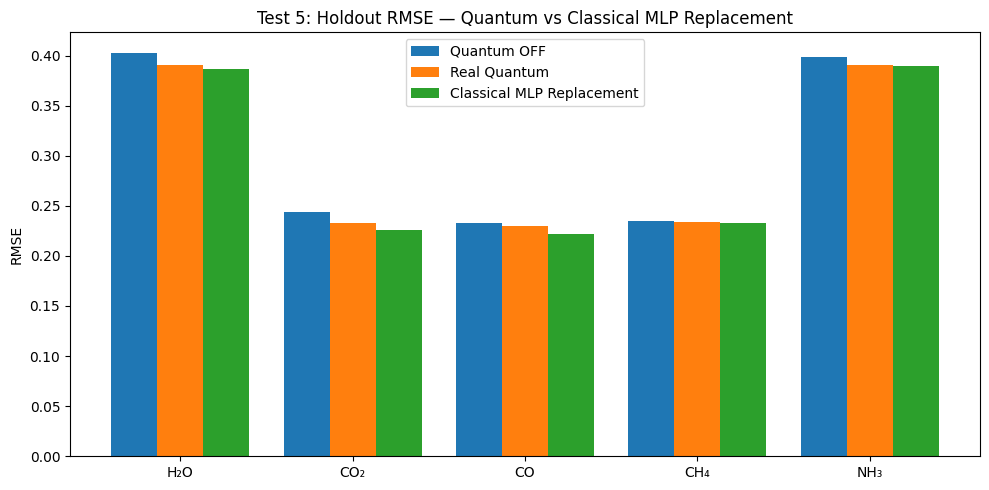

In [6]:
fig = plot_per_target(comparison, "Test 5: Holdout RMSE — Quantum vs Classical MLP Replacement")
plt.show()

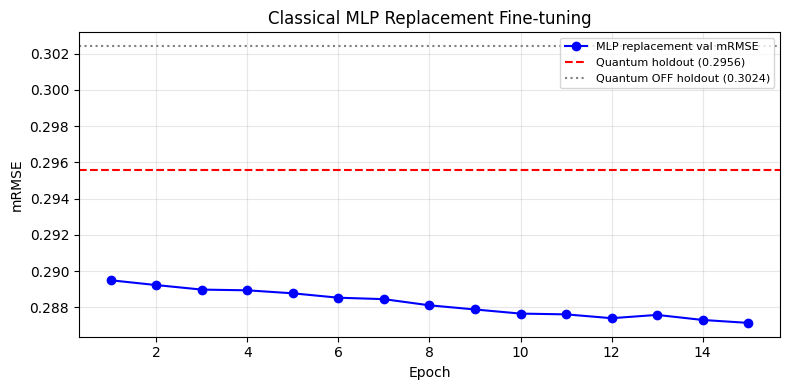

In [7]:
# Training curve
hdf = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hdf["epoch"], hdf["val_mrmse"], "b-o", label="MLP replacement val mRMSE")
ax.axhline(holdout_quantum["rmse_mean"], color="red", linestyle="--", label=f"Quantum holdout ({holdout_quantum['rmse_mean']:.4f})")
ax.axhline(holdout_off["rmse_mean"], color="gray", linestyle=":", label=f"Quantum OFF holdout ({holdout_off['rmse_mean']:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("mRMSE")
ax.set_title("Classical MLP Replacement Fine-tuning")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Verdict
q_mrmse = holdout_quantum["rmse_mean"]
mlp_mrmse = holdout_mlp["rmse_mean"]

print("=== Test 5 Verdict ===")
print(f"Quantum circuit:       {q_mrmse:.4f}")
print(f"Classical replacement: {mlp_mrmse:.4f}")
print(f"Delta (MLP - Quantum): {mlp_mrmse - q_mrmse:+.4f}")

if mlp_mrmse > q_mrmse + 0.002:
    print("VERDICT: Quantum circuit outperforms classical replacement — quantum advantage signal.")
elif abs(mlp_mrmse - q_mrmse) < 0.002:
    print("VERDICT: Classical replacement ≈ quantum — no quantum advantage from circuit.")
else:
    print("VERDICT: Classical replacement beats quantum — quantum circuit is suboptimal.")

=== Test 5 Verdict ===
Quantum circuit:       0.2956
Classical replacement: 0.2913
Delta (MLP - Quantum): -0.0043
VERDICT: Classical replacement beats quantum — quantum circuit is suboptimal.
